In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from dask.distributed import Client
import numpy as np
import pandas as pd
import glob
import tqdm

In [2]:
client = Client()

In [3]:
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46473,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:36465,Total threads: 2
Dashboard: /proxy/44479/status,Memory: 9.00 GiB
Nanny: tcp://127.0.0.1:34045,


## Workflow to generate the below data
* Run the sea breeze identification (`barra_c/filter_jobs/filter_F_driver.sh`)
* Define the shapes of the coastal zones for defining sea breeze days for each offshore wind area (`coastal_shapes.py`)
* Resample to daily max (in local time) and define SB days for each REZ (`composite_analysis/daily_resample.sh`)
* Composite variables for SB days and non SB days in a set of regions, on a monthly basis, and average to seasonal (`sea_breeze_composite_*.sh`)

In [4]:
def load_composite(region):

    sb = []
    nonsb = []
    for season in ["ANN","DJF","MAM","JJA","SON"]:
        sb.append(xr.open_dataset("/g/data/ng72/ab4502/hourly_composites/barra_c/barra_c_hourly_sb_composite_"+region+"_"+season+".nc",chunks={}))
        nonsb.append(xr.open_dataset("/g/data/ng72/ab4502/hourly_composites/barra_c/barra_c_hourly_nonsb_composite_"+region+"_"+season+".nc",chunks={}))
    
    sb = xr.concat(sb,dim="season").persist()
    nonsb = xr.concat(nonsb,dim="season").persist()
    
    sb["season"] = ["ANN","DJF","MAM","JJA","SON"]
    nonsb["season"] = ["ANN","DJF","MAM","JJA","SON"]

    return sb, nonsb

gipps_sb, gipps_non_sb = load_composite("gipps")
bunbury_sb, bunbury_non_sb = load_composite("bunbury")
illawarra_sb, illawara_non_sb = load_composite("illawara")
newcastle_sb, newcastle_non_sb = load_composite("newcastle")
sa_sb, sa_non_sb = load_composite("sa")
southern_sb, southern_non_sb = load_composite("southern")
tas_sb, tas_non_sb = load_composite("tas")

In [5]:
#Load sb days for each region

def read_csv(path):

    df = pd.read_csv(path)
    df["time"] = pd.to_datetime(df["time"])
    return df.set_index("time").loc[slice("1979-01-01","2024-12-31 23:00")]

#Plot demand on sb days and non sb days for each region
bunbury_sb_days = read_csv("/g/data/ng72/ab4502/sea_breeze_detection/barra_c_smooth_s2/sb_days/bunbury.csv")
gipps_sb_days = read_csv("/g/data/ng72/ab4502/sea_breeze_detection/barra_c_smooth_s2/sb_days/gipps.csv")
illawara_sb_days = read_csv("/g/data/ng72/ab4502/sea_breeze_detection/barra_c_smooth_s2/sb_days/illawara.csv")
newcastle_sb_days = read_csv("/g/data/ng72/ab4502/sea_breeze_detection/barra_c_smooth_s2/sb_days/newcastle.csv")
sa_sb_days = read_csv("/g/data/ng72/ab4502/sea_breeze_detection/barra_c_smooth_s2/sb_days/sa.csv")
southern_sb_days = read_csv("/g/data/ng72/ab4502/sea_breeze_detection/barra_c_smooth_s2/sb_days/southern.csv")
tas_sb_days = read_csv("/g/data/ng72/ab4502/sea_breeze_detection/barra_c_smooth_s2/sb_days/tas.csv")

In [6]:
shapes = xr.open_dataset("/g/data/ng72/ab4502/coastline_data/rez_coastal_shapes.nc").sel(lat=gipps_sb.lat,lon=gipps_sb.lon)
shapes_bunbury = xr.open_dataset("/g/data/ng72/ab4502/coastline_data/rez_coastal_shapes.nc").sel(lat=bunbury_sb.lat,lon=bunbury_sb.lon)

In [7]:
# shapes_bunbury.bunbury_landsea.plot()
# xr.plot.contour((shapes_bunbury["rez_mask"]==43))

#Gipps=27
#Illawarra=19
#Newcastle=18
#Southern=28
#SA=38
#Tas=42
#Bunbury onshore=43
#Bunbury offshore=44

In [8]:
def load_nemosis(path,region=None):

    df = pd.read_csv(path,skiprows=[0])
    df["SETTLEMENTDATE"] = pd.to_datetime(df["SETTLEMENTDATE"])
    df = df[["SETTLEMENTDATE","REGIONID","TOTALDEMAND"]].dropna()
    df = df.drop_duplicates(["SETTLEMENTDATE","REGIONID"])
    
    if region is None:
        df = df.groupby("SETTLEMENTDATE").sum()
        df = df.loc[df.index.minute == 0]
        return df[["TOTALDEMAND"]]
    else:
        df = df[df["REGIONID"]==region]
        df = df.set_index("SETTLEMENTDATE").sort_index()
        df = df.loc[df.index.minute == 0]
        return df

nemosis_files = np.sort(glob.glob("/g/data/ng72/ab4502/nemosis/*.CSV"))
demand_nsw = pd.concat([load_nemosis(f,"NSW1") for f in tqdm.tqdm(nemosis_files)],axis=0)
demand_vic = pd.concat([load_nemosis(f,"VIC1") for f in tqdm.tqdm(nemosis_files)],axis=0)
demand_sa = pd.concat([load_nemosis(f,"SA1") for f in tqdm.tqdm(nemosis_files)],axis=0)
demand_tas = pd.concat([load_nemosis(f,"TAS1") for f in tqdm.tqdm(nemosis_files)],axis=0)

100%|██████████| 122/122 [00:40<00:00,  2.98it/s]


In [9]:
demand_nsw = demand_nsw.iloc[(np.in1d(demand_nsw.index.month,[12,1,2])) & (demand_nsw.index.year >= 2010) & (demand_nsw.index.year <= 2019)]
demand_vic = demand_vic.iloc[(np.in1d(demand_vic.index.month,[12,1,2])) & (demand_vic.index.year >= 2010) & (demand_vic.index.year <= 2019)]
demand_sa = demand_sa.iloc[(np.in1d(demand_sa.index.month,[12,1,2])) & (demand_sa.index.year >= 2010) & (demand_sa.index.year <= 2019)]
demand_tas = demand_tas.iloc[(np.in1d(demand_tas.index.month,[12,1,2])) & (demand_tas.index.year >= 2010) & (demand_tas.index.year <= 2019)]

In [10]:
def load_wa_demand(path):
    df = pd.read_csv(path)
    df = df.set_index(pd.to_datetime(df["Trading Interval"])).rename(columns={"Operational Demand (MW)":"TOTALDEMAND"})[["TOTALDEMAND"]]
    df = df.loc[df.index.minute == 0]
    df = df.drop_duplicates()
    return df


wa_demand_files = np.sort(glob.glob("/g/data/ng72/ab4502/wa_demand/operational-demand-*.csv"))
demand_wa = pd.concat([load_wa_demand(f) for f in tqdm.tqdm(wa_demand_files)],axis=0)
demand_wa = demand_wa.iloc[(np.in1d(demand_wa.index.month,[12,1,2])) & (demand_wa.index.year >= 2010) & (demand_wa.index.year <= 2019)]

100%|██████████| 10/10 [00:01<00:00,  8.98it/s]


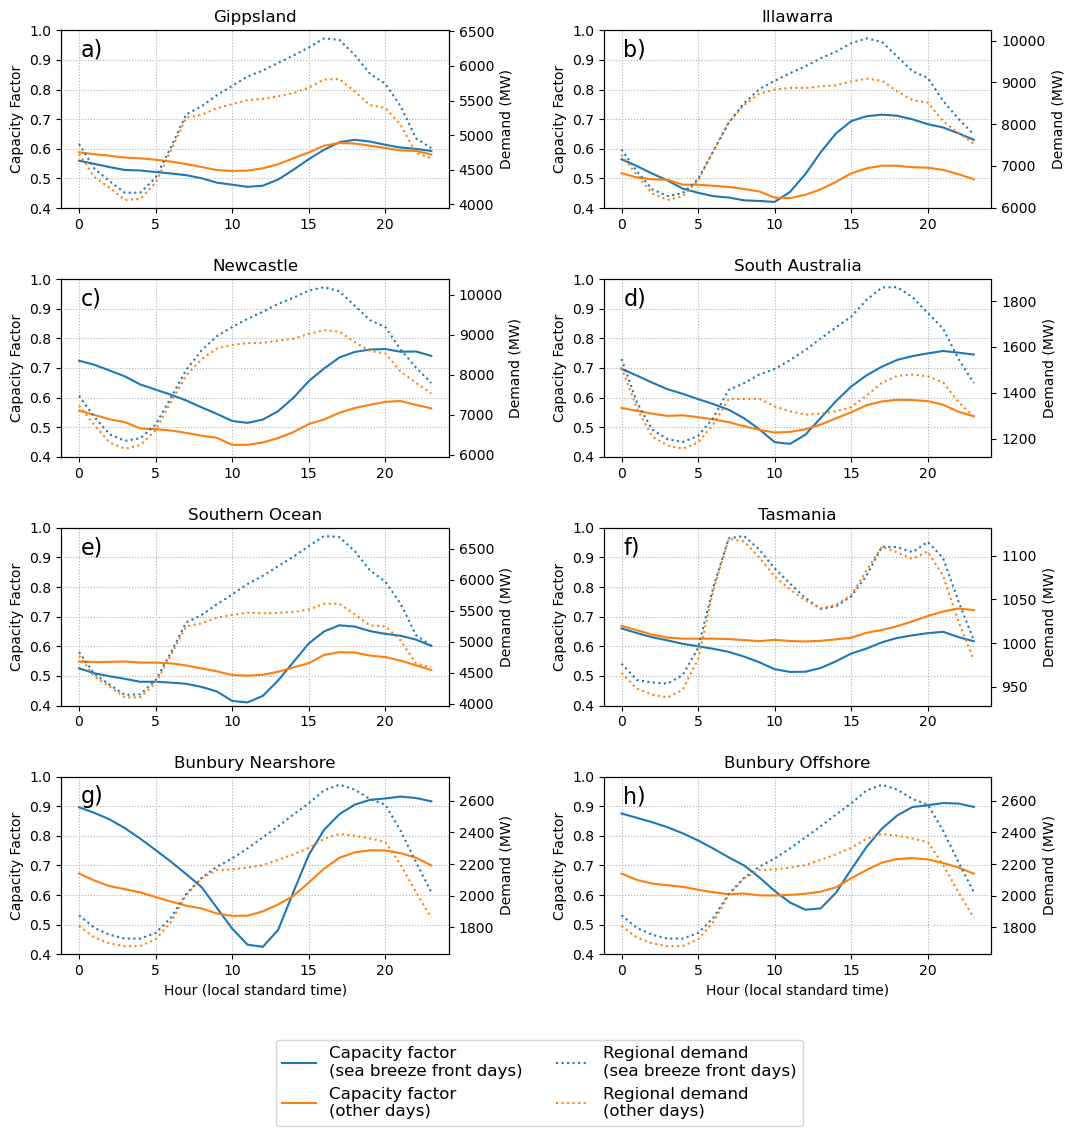

In [11]:
def plot(mask,sb,non_sb,var,season="DJF",title="",demand=None,sb_days=None,letter=""):
    l1=xr.where(
        mask,
        sb.sel(season=season)[var],
        np.nan).mean(("lat","lon")).plot(color="tab:blue")
    l2=xr.where(
        mask,
        non_sb.sel(season=season)[var],
        np.nan).mean(("lat","lon")).plot(color="tab:orange")
    plt.title(title)

    if var=="u":
        plt.ylim([-7,7])
    elif var=="v":
        plt.ylim([-12,12])
    elif var=="cf":
        plt.ylim([0.4,1])

    plt.xlabel("")
    plt.gca().grid(ls=":")
    plt.ylabel("Capacity Factor")

    plt.gca().text(0.05,0.85,letter+")",transform=plt.gca().transAxes,fontdict={"size":"16"})


    
    if demand is not None:

        
        sb_demand = demand.loc[np.in1d(demand.index.date,sb_days.query("sb==1").index.date)]
        nonsb_demand = demand.loc[np.in1d(demand.index.date,sb_days.query("sb==0").index.date)]
        
        ax2 = plt.gca().twinx()
        l3=ax2.plot(sb_demand.TOTALDEMAND.groupby(sb_demand.index.hour).mean(),color="tab:blue",ls=":")
        l4=ax2.plot(nonsb_demand.TOTALDEMAND.groupby(nonsb_demand.index.hour).mean(),color="tab:orange",ls=":")
        #l3=ax2.plot(demand["TOTALDEMAND"].groupby(demand.index.hour).mean(),color="k",ls=":")
        ax2.set_ylabel("Demand (MW)")
        return l1,l2,l3,l4
    else:
        return l1,l2

fig=plt.figure(figsize=[12,12])

plt.subplot(4,2,1)
plot(shapes["rez_mask"]==27, gipps_sb, gipps_non_sb, "cf", demand=demand_vic, sb_days=gipps_sb_days, title="Gippsland", letter="a")

plt.subplot(4,2,2)
plot(shapes["rez_mask"]==19, illawarra_sb, illawara_non_sb, "cf",title="Illawarra", demand=demand_nsw, sb_days=illawara_sb_days, letter="b")

plt.subplot(4,2,3)
plot(shapes["rez_mask"]==18, newcastle_sb, newcastle_non_sb, "cf",title="Newcastle", demand=demand_nsw, sb_days=newcastle_sb_days, letter="c")

plt.subplot(4,2,4)
plot(shapes["rez_mask"]==38, sa_sb, sa_non_sb, "cf",title="South Australia", demand=demand_sa, sb_days=sa_sb_days, letter="d")

plt.subplot(4,2,5)
plot(shapes["rez_mask"]==28, southern_sb, southern_non_sb, "cf",title="Southern Ocean", demand=demand_vic, sb_days=southern_sb_days, letter="e")

plt.subplot(4,2,6)
l1,l2,l3,l4=plot(shapes["rez_mask"]==42, tas_sb, tas_non_sb, "cf", demand=demand_tas, title="Tasmania", sb_days=tas_sb_days, letter="f")

ax=plt.subplot(4,2,7)
plot(shapes_bunbury["rez_mask"]==43, bunbury_sb, bunbury_non_sb, "cf", demand=demand_wa, title="Bunbury Nearshore", sb_days=bunbury_sb_days, letter="g")
ax.set_xlabel("Hour (local standard time)")

ax=plt.subplot(4,2,8)
plot(shapes_bunbury["rez_mask"]==44, bunbury_sb, bunbury_non_sb, "cf",demand=demand_wa, title="Bunbury Offshore", sb_days=bunbury_sb_days, letter="h")
ax.set_xlabel("Hour (local standard time)")

fig.legend([l1[0],l2[0],l3[0],l4[0]],
           ["Capacity factor\n(sea breeze front days)","Capacity factor\n(other days)","Regional demand\n(sea breeze front days)","Regional demand\n(other days)"],
           loc="lower right", bbox_to_anchor=[0.75,-0.04],ncols=2,fontsize="large")

plt.subplots_adjust(hspace=0.4,wspace=0.4)

plt.savefig("/g/data/ng72/ab4502/figs/wind_energy_paper/cf_sb_days.jpeg",bbox_inches="tight",dpi=300)

In [12]:
mask = shapes_bunbury["rez_mask"]==43

season = "DJF" 

sb = bunbury_sb

non_sb = bunbury_non_sb

var = "cf"

print(
    xr.where(
        mask,
        sb.sel(season=season)[var],
        np.nan).mean(("lat","lon")).rename(var).to_dataframe(),
    xr.where(
        mask,
        non_sb.sel(season=season)[var],
        np.nan).mean(("lat","lon")).rename(var).to_dataframe()
)

      crs       time  region abbrevs                    names season        cf
hour                                                                          
0       0 2024-12-01      42     r42  T4 North Tasmania Coast    DJF  0.896652
1       0 2024-12-01      42     r42  T4 North Tasmania Coast    DJF  0.877802
2       0 2024-12-01      42     r42  T4 North Tasmania Coast    DJF  0.855490
3       0 2024-12-01      42     r42  T4 North Tasmania Coast    DJF  0.825956
4       0 2024-12-01      42     r42  T4 North Tasmania Coast    DJF  0.790417
5       0 2024-12-01      42     r42  T4 North Tasmania Coast    DJF  0.752175
6       0 2024-12-01      42     r42  T4 North Tasmania Coast    DJF  0.712953
7       0 2024-12-01      42     r42  T4 North Tasmania Coast    DJF  0.670820
8       0 2024-12-01      42     r42  T4 North Tasmania Coast    DJF  0.627097
9       0 2024-12-01      42     r42  T4 North Tasmania Coast    DJF  0.557015
10      0 2024-12-01      42     r42  T4 North Tasma

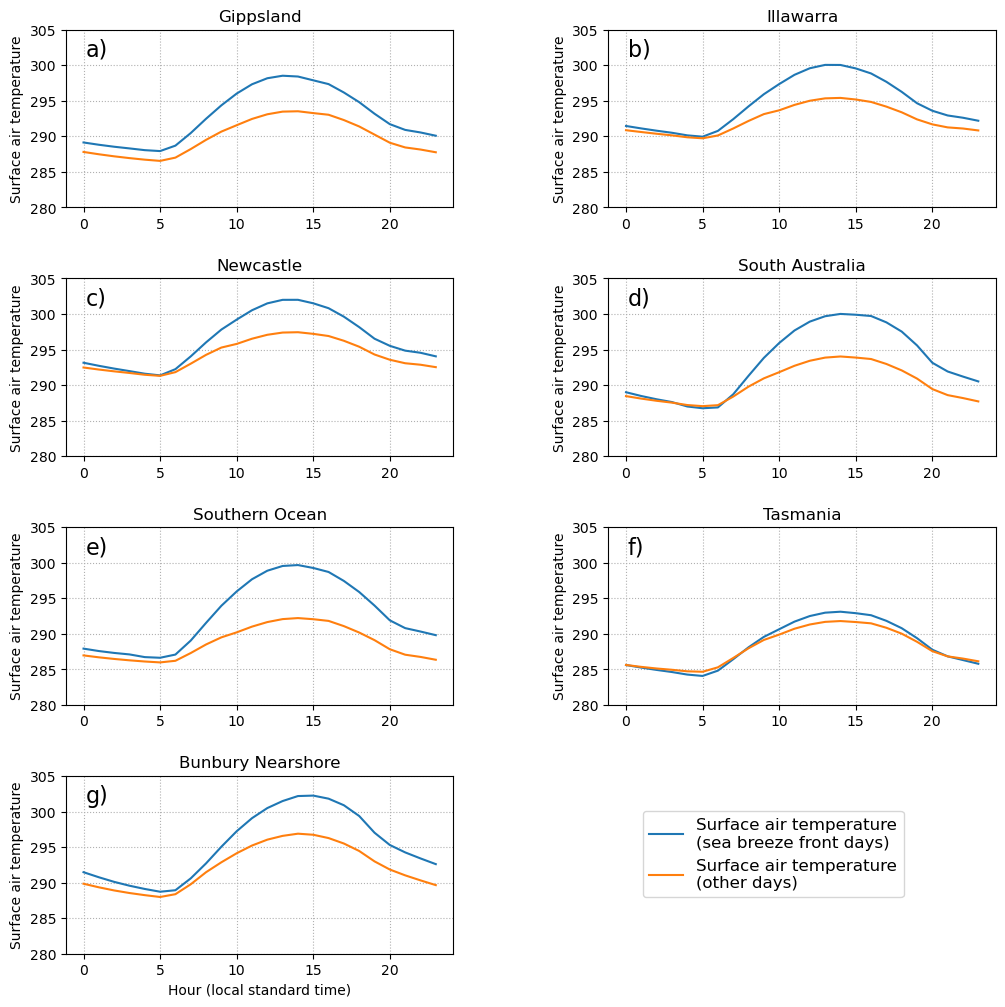

In [13]:
def plot(mask,sb,non_sb,var,season="DJF",title="",demand=None,sb_days=None,letter=""):
    l1=xr.where(
        mask,
        sb.sel(season=season)[var],
        np.nan).mean(("lat","lon")).plot(color="tab:blue")
    l2=xr.where(
        mask,
        non_sb.sel(season=season)[var],
        np.nan).mean(("lat","lon")).plot(color="tab:orange")
    plt.title(title)

    if var=="u":
        plt.ylim([-7,7])
    elif var=="v":
        plt.ylim([-12,12])
    elif var=="cf":
        plt.ylim([0.4,1])
    elif var=="tas":
        plt.ylim([280,305])

    plt.xlabel("")
    plt.gca().grid(ls=":")
    plt.ylabel("Surface air temperature")

    plt.gca().text(0.05,0.85,letter+")",transform=plt.gca().transAxes,fontdict={"size":"16"})

    return l1,l2

fig=plt.figure(figsize=[12,12])

plt.subplot(4,2,1)
plot(shapes.gipps, gipps_sb, gipps_non_sb, "tas", demand=demand_vic, sb_days=gipps_sb_days, title="Gippsland",letter="a")

plt.subplot(4,2,2)
plot(shapes.illawara, illawarra_sb, illawara_non_sb, "tas",title="Illawarra", demand=demand_nsw, sb_days=illawara_sb_days,letter="b")

plt.subplot(4,2,3)
plot(shapes.newcastle, newcastle_sb, newcastle_non_sb, "tas",title="Newcastle", demand=demand_nsw, sb_days=newcastle_sb_days,letter="c")

plt.subplot(4,2,4)
plot(shapes.sa, sa_sb, sa_non_sb, "tas",title="South Australia", demand=demand_sa, sb_days=sa_sb_days,letter="d")

plt.subplot(4,2,5)
plot(shapes.southern, southern_sb, southern_non_sb, "tas",title="Southern Ocean", demand=demand_vic, sb_days=southern_sb_days,letter="e")

plt.subplot(4,2,6)
l1,l2=plot(shapes.tas, tas_sb, tas_non_sb, "tas", demand=demand_tas, title="Tasmania", sb_days=tas_sb_days,letter="f")

ax=plt.subplot(4,2,7)
plot(shapes_bunbury.bunbury, bunbury_sb, bunbury_non_sb, "tas", demand=demand_wa, title="Bunbury Nearshore", sb_days=bunbury_sb_days,letter="g")
ax.set_xlabel("Hour (local standard time)")

# ax=plt.subplot(4,2,8)
# plot(shapes.bu, bunbury_sb, bunbury_non_sb, "tas",demand=demand_wa, title="Bunbury Offshore", sb_days=bunbury_sb_days)
# ax.set_xlabel("Hour (local standard time)")

fig.legend([l1[0],l2[0],l3[0],l4[0]],
           ["Surface air temperature\n(sea breeze front days)","Surface air temperature\n(other days)"],
           loc="lower right", bbox_to_anchor=[0.83,.15],ncols=1,fontsize="large")

plt.subplots_adjust(hspace=0.4,wspace=0.4)

plt.savefig("/g/data/ng72/ab4502/figs/wind_energy_paper/tas_sb_days.jpeg",bbox_inches="tight",dpi=300)

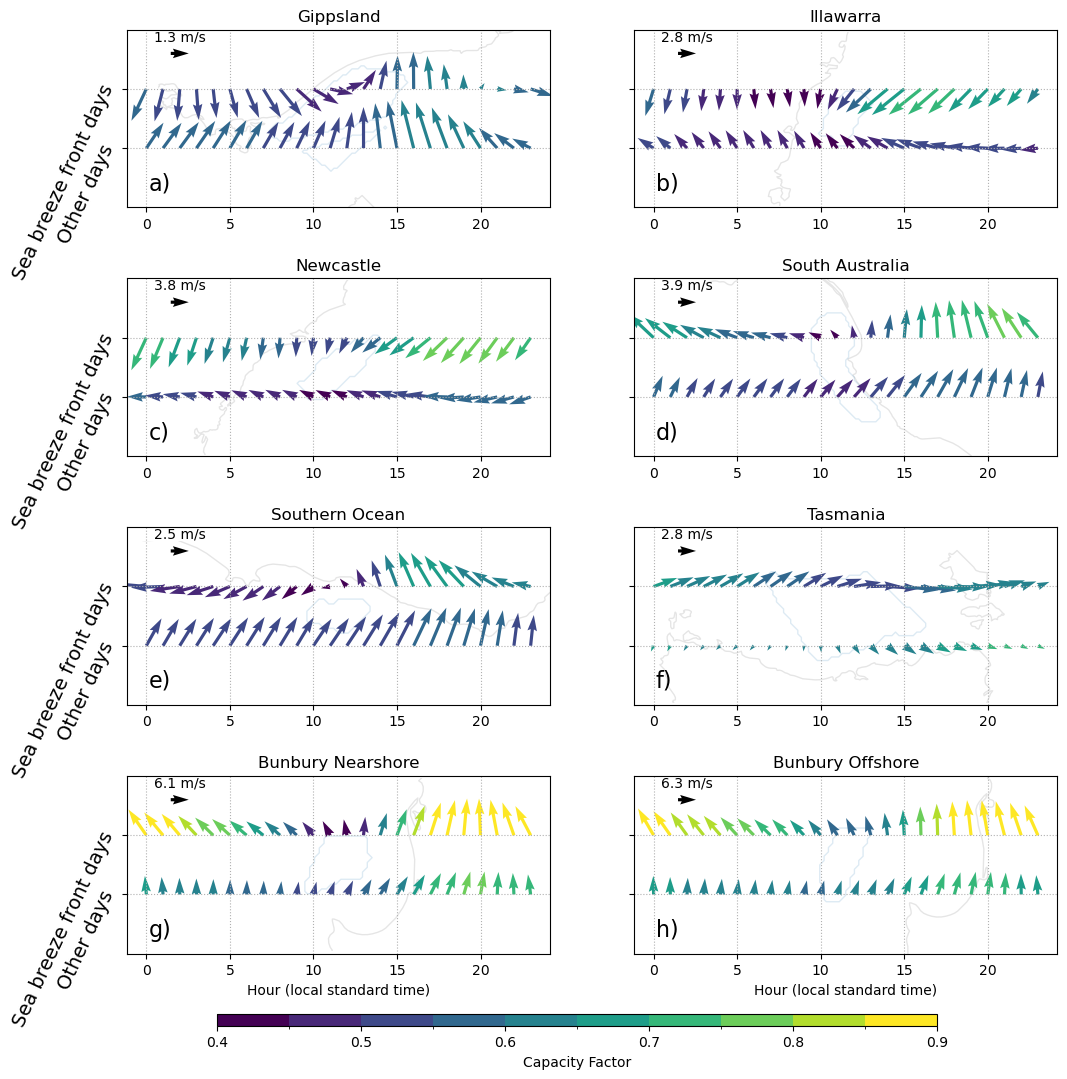

In [14]:
def plot_comp_quiver(mask,temp_sb,temp_non_sb,ax,add_yticklabels=True,title="",letter=""):


    xx,yy = np.meshgrid(mask.lon,mask.lat)
    lon = [xr.where(mask,xx,np.nan).min() - 1.5, xr.where(mask,xx,np.nan).max() + 1.5]
    lat = [xr.where(mask,yy,np.nan).min() - 0.5, xr.where(mask,yy,np.nan).max() + 0.5]
    
    temp_sb = xr.merge([temp_sb,xr.DataArray(np.array([0]*24),dims=["hour"]).rename("y")])
    temp_sb = xr.where(
            mask,
            temp_sb,
            np.nan).mean(("lat","lon"))
    
    
    temp_non_sb = xr.merge([temp_non_sb,xr.DataArray(np.array([-1]*24),dims=["hour"]).rename("y")])
    temp_non_sb = xr.where(
            mask,
            temp_non_sb,
            np.nan).mean(("lat","lon"))

    scale = np.sqrt(temp_sb.u.values**2 + temp_sb.v.values**2).mean() / 1.5
    
    plot_quiver(temp_sb,ax,s=scale)
    Q=plot_quiver(temp_non_sb,ax,add_key=True,s=scale,u_qk=scale)
    
    ax.set_ylim([-2,1])
    ax.set_title("")

    if add_yticklabels:
        ax.set_yticks([-1,0],["Other days","Sea breeze front days"],rotation=65,size=14)
    else:
        ax.set_yticks([-1,0],["",""])
    
    ax2 = ax.inset_axes([0,0,1,1],zorder=0,projection=ccrs.PlateCarree())
    ax2.set_xlim(lon)
    ax2.set_ylim(lat)
    ax2.coastlines(alpha=0.1,color="k")
    xr.plot.contour(mask, ax=ax2, colors=["tab:blue"], linewidths=1, levels=1,alpha=0.15)
    ax2.set_title("")
    ax2.set_axis_off()

    ax.grid(ls=":")

    ax.text(0.05,0.1,letter+")",transform=ax.transAxes,fontdict={"size":"16"})

    plt.title(title)

    return Q

def plot_quiver(temp,ax,s=4,add_key=False,u_qk=1):

    from matplotlib.colors import BoundaryNorm
    
    x = temp.hour
    y = temp.y
    u = temp.u
    v = temp.v
    c = temp.cf
    
    cmap = plt.get_cmap("viridis")
    
    boundaries = np.arange(0.4,0.95,0.05)
    norm = BoundaryNorm(boundaries, ncolors=256, clip=True)
    Q=ax.quiver(x,y,u,v,c,norm=norm,cmap=cmap,scale=s,units="xy")
    if add_key:
        plt.quiverkey(Q,2,0.6,u_qk,label=str(np.round(u_qk,1))+" m/s",coordinates="data")
    return Q

fig=plt.figure(figsize=[12,12])

plot_comp_quiver(shapes["rez_mask"]==27, gipps_sb.sel(season="DJF"), gipps_non_sb.sel(season="DJF"), plt.subplot(4,2,1),title="Gippsland",letter="a")
plot_comp_quiver(shapes["rez_mask"]==19, illawarra_sb.sel(season="DJF"), illawara_non_sb.sel(season="DJF"), plt.subplot(4,2,2),add_yticklabels=False,title="Illawarra",letter="b")
plot_comp_quiver(shapes["rez_mask"]==18, newcastle_sb.sel(season="DJF"), newcastle_non_sb.sel(season="DJF"), plt.subplot(4,2,3),title="Newcastle",letter="c")
plot_comp_quiver(shapes["rez_mask"]==38, sa_sb.sel(season="DJF"), sa_non_sb.sel(season="DJF"), plt.subplot(4,2,4),add_yticklabels=False,title="South Australia",letter="d")
plot_comp_quiver(shapes["rez_mask"]==28, southern_sb.sel(season="DJF"), southern_non_sb.sel(season="DJF"), plt.subplot(4,2,5),title="Southern Ocean",letter="e")
plot_comp_quiver(shapes["rez_mask"]==42, tas_sb.sel(season="DJF"), tas_non_sb.sel(season="DJF"), plt.subplot(4,2,6),add_yticklabels=False,title="Tasmania",letter="f")
plot_comp_quiver(shapes_bunbury["rez_mask"]==43, bunbury_sb.sel(season="DJF"), bunbury_non_sb.sel(season="DJF"), plt.subplot(4,2,7),title="Bunbury Nearshore",letter="g")
plt.xlabel("Hour (local standard time)")
Q = plot_comp_quiver(shapes_bunbury["rez_mask"]==44, bunbury_sb.sel(season="DJF"), bunbury_non_sb.sel(season="DJF"), plt.subplot(4,2,8),add_yticklabels=False,title="Bunbury Offshore",letter="h")
plt.xlabel("Hour (local standard time)")

cb=plt.colorbar(Q,cax=plt.axes([0.2,0.05,0.6,0.01]),orientation="horizontal")
cb.set_label("Capacity Factor")

plt.subplots_adjust(hspace=0.4)

plt.savefig("/g/data/ng72/ab4502/figs/wind_energy_paper/quiver_sb_days.jpeg",bbox_inches="tight",dpi=300)

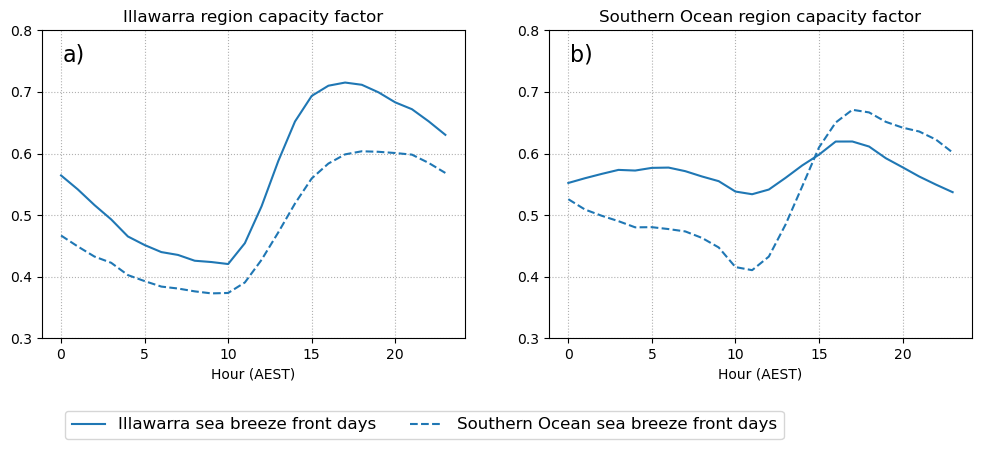

In [15]:
def plot(mask,sb,var,season="DJF",title="",label="",color="tab:blue",ls="-"):
    l=xr.where(
        mask,
        sb.sel(season=season)[var],
        np.nan).mean(("lat","lon")).plot(ls=ls,color=color,add_legend=False)

    if var=="u":
        plt.ylim([-7,7])
    elif var=="v":
        plt.ylim([-12,12])
    elif var=="cf":
        plt.ylim([0.3,0.8])

    plt.gca().grid(ls=":")
    
    return l

fig=plt.figure(figsize=[12,4])

plt.subplot(1,2,1)
l1=plot(shapes["rez_mask"]==19, illawarra_sb, "cf",title="Illawarra",label="Illawarra SBF days",ls="-")
#l2=plot(shapes["rez_mask"]==19, newcastle_sb, "cf",title="Illawarra",label="Newcastle SB days")
#l3=plot(shapes["rez_mask"]==19, gipps_sb, "cf",title="Illawarra",label="Gippsland SB days")
#l4=plot(shapes["rez_mask"]==19, tas_sb, "cf",title="Illawarra",label="Tasmania SB days")
l5=plot(shapes["rez_mask"]==19, southern_sb, "cf",title="Illawarra",label="Southern Ocean SBF days",ls="--")
#l6=plot(shapes["rez_mask"]==19, sa_sb, "cf",title="Illawarra average capacity factor",label="South Australia SB days")
plt.title("Illawarra region capacity factor")
plt.xlabel("Hour (AEST)")
plt.gca().text(0.05,0.9,"a)",transform=plt.gca().transAxes,fontdict={"size":"16"})

plt.subplot(1,2,2)
l1=plot(shapes["rez_mask"]==28, illawarra_sb, "cf",title="",label="Illawarra",ls="-")
#plot(shapes["rez_mask"]==28, newcastle_sb, "cf",title="",label="Newcastle")
#plot(shapes["rez_mask"]==28, gipps_sb, "cf",title="",label="Gippsland")
#plot(shapes["rez_mask"]==28, tas_sb, "cf",title="",label="Tasmania")
l2=plot(shapes["rez_mask"]==28, southern_sb, "cf",title="",label="Southern Ocean",ls="--")
#plot(shapes["rez_mask"]==28, sa_sb, "cf",title="Southern ocean average capacity factor",label="South Australia")
plt.title("Southern Ocean region capacity factor")
plt.xlabel("Hour (AEST)")
plt.gca().text(0.05,0.9,"b)",transform=plt.gca().transAxes,fontdict={"size":"16"})

fig.legend([l1[0],l2[0]],["Illawarra sea breeze front days","Southern Ocean sea breeze front days"],ncols=2,bbox_to_anchor=[0.75,-0.05],fontsize="large")

plt.savefig("/g/data/ng72/ab4502/figs/wind_energy_paper/cf_co_occurrence.jpeg",bbox_inches="tight",dpi=300)

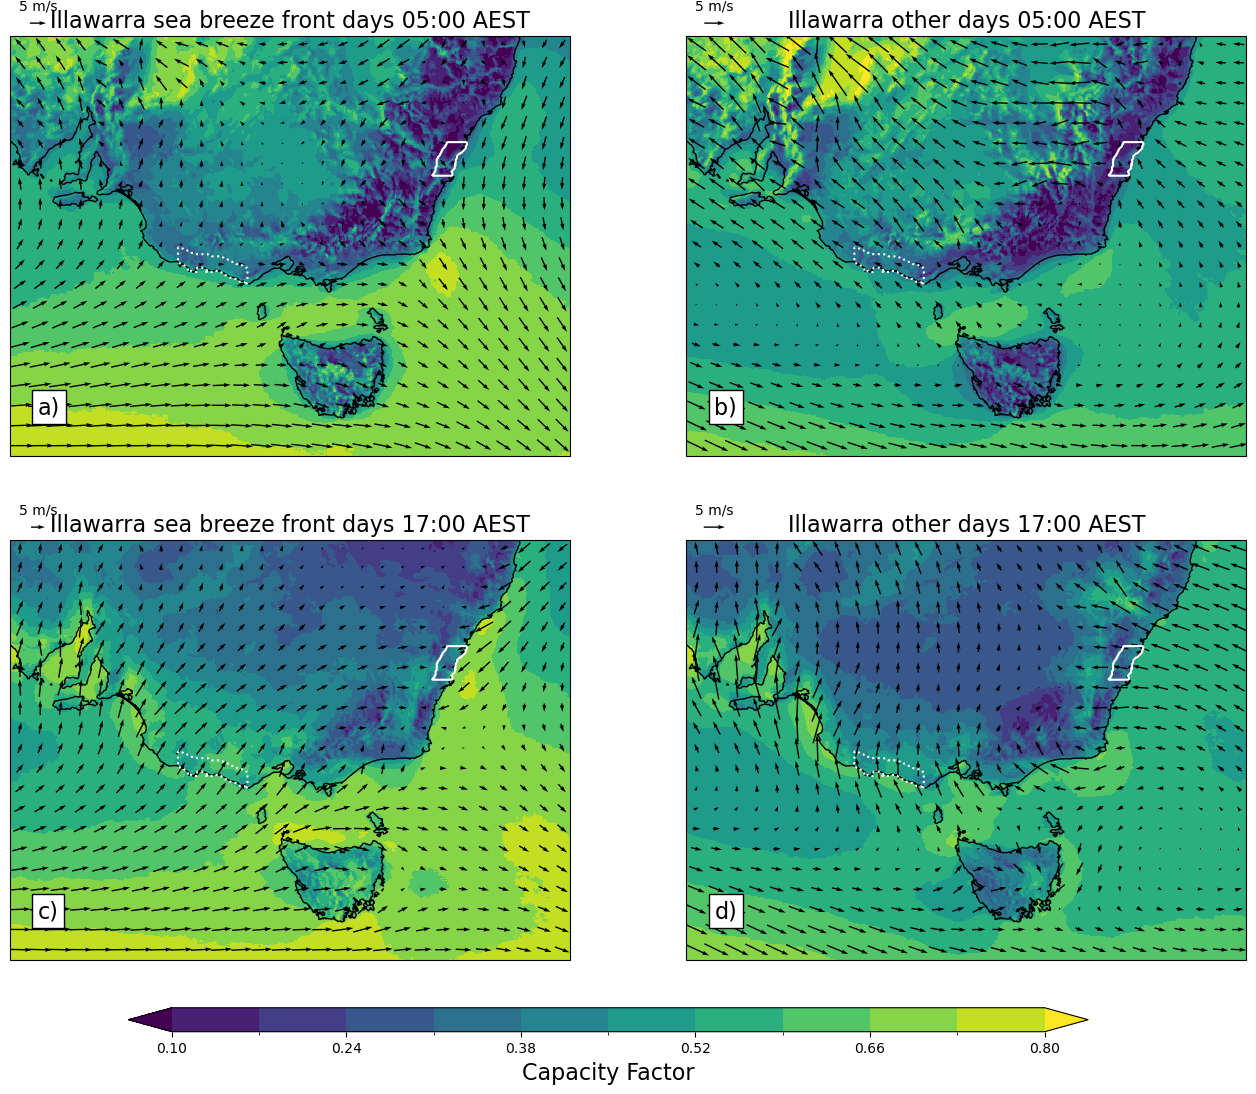

In [16]:
def plot_map(sb_avg,nonsb_avg,h,ax1,ax2,shapes,shape1,shape2,lat_slice=slice(-45,-30),lon_slice=slice(135,155),c=10):

    c=18
    
    if h == "mean":
        sb_avg = sb_avg.mean("hour")
        nonsb_avg = nonsb_avg.mean("hour")
    else:
        sb_avg = sb_avg.sel(hour=h)
        nonsb_avg = nonsb_avg.sel(hour=h)
    
    
    sb_avg.sel(lat=lat_slice,lon=lon_slice).cf.plot(levels=np.linspace(0.1,0.8,11),ax=ax1,extend="both",add_colorbar=False)
    q=sb_avg.sel(lat=lat_slice,lon=lon_slice).coarsen({"lat":c,"lon":c},boundary="pad").mean().plot.quiver(x="lon",y="lat",u="u",v="v",ax=ax1,add_guide=False)
    qk=plt.quiverkey(q,0.05,1.03,5,"5 m/s")
    ax1.coastlines()

    xr.plot.contour(
        xr.where(shapes["lsm"],
                shapes[shape1],
            0),
        levels=1,colors=["white"],linewidths=1.5,ax=ax1)
    xr.plot.contour(
        xr.where(shapes["lsm"],
                shapes[shape2],
            0),
        levels=1,colors=["white"],linewidths=1.5,linestyles=[":"],ax=ax1)    
    
    p=nonsb_avg.sel(lat=lat_slice,lon=lon_slice).cf.plot(levels=np.linspace(0.1,0.8,11),ax=ax2,extend="both",add_colorbar=False)
    q=nonsb_avg.sel(lat=lat_slice,lon=lon_slice).coarsen({"lat":c,"lon":c},boundary="pad").mean().plot.quiver(x="lon",y="lat",u="u",v="v",ax=ax2,add_guide=False)
    qk=plt.quiverkey(q,0.05,1.03,5,"5 m/s")
    ax2.coastlines()

    xr.plot.contour(
        xr.where(shapes["lsm"],
                shapes[shape1],
            0),
        levels=1,colors=["white"],linewidths=1.5,ax=ax2)
    xr.plot.contour(
        xr.where(shapes["lsm"],
                shapes[shape2],
            0),
        levels=1,colors=["white"],linewidths=1.5,linestyles=[":"],ax=ax2)   

    return p


plt.figure(figsize=[16,12])

ax1=plt.subplot(2,2,1,projection=ccrs.PlateCarree())
ax2=plt.subplot(2,2,2,projection=ccrs.PlateCarree())
plot_map(illawarra_sb.sel(season="DJF"),illawara_non_sb.sel(season="DJF"),5,ax1,ax2,shapes,"illawara_landsea","southern_landsea")#,lat_slice=slice(-42,-27),lon_slice=slice(108,130))
ax1.set_title("Illawarra sea breeze front days 05:00 AEST",size=16)
ax2.set_title("Illawarra other days 05:00 AEST",size=16)

ax1.text(0.05,0.1,"a)",transform=ax1.transAxes,fontdict={"size":"16"},bbox=dict(facecolor='white'))
ax2.text(0.05,0.1,"b)",transform=ax2.transAxes,fontdict={"size":"16"},bbox=dict(facecolor='white'))

# c=xr.plot.contourf(
#     xr.where(shapes["rez_mask"].isin([27,19,18,28,38,42,43]),shapes["rez_mask"],np.nan),add_colorbar=False,cmap="tab10",levels=levels)

# c_orog = xr.where(shapes["lsm"],orog.sel(lat=shapes.lat,lon=shapes.lon).orog,np.nan).plot(vmin=0,vmax=1500,cmap="terrain",extend="max",add_colorbar=False)

ax1=plt.subplot(2,2,3,projection=ccrs.PlateCarree())
ax2=plt.subplot(2,2,4,projection=ccrs.PlateCarree())
c=plot_map(illawarra_sb.sel(season="DJF"),illawara_non_sb.sel(season="DJF"),17,ax1,ax2,shapes,"illawara_landsea","southern_landsea")#,lat_slice=slice(-42,-27),lon_slice=slice(108,130))
ax1.set_title("Illawarra sea breeze front days 17:00 AEST",size=16)
ax2.set_title("Illawarra other days 17:00 AEST",size=16)

ax1.text(0.05,0.1,"c)",transform=ax1.transAxes,fontdict={"size":"16"},bbox=dict(facecolor='white'))
ax2.text(0.05,0.1,"d)",transform=ax2.transAxes,fontdict={"size":"16"},bbox=dict(facecolor='white'))

cb=plt.colorbar(c,cax=plt.axes([0.2,0.05,0.6,0.02]),orientation="horizontal")
cb.set_label("Capacity Factor",size=16)

plt.savefig("/g/data/ng72/ab4502/figs/wind_energy_paper/illawarra_composite_map.jpeg",bbox_inches="tight",dpi=300)

/jobfs/154345870.gadi-pbs/ipykernel_861294/2427301965.py:20: UserWarning: Adding colorbar to a different Figure <Figure size 1600x1200 with 5 Axes> than <Figure size 1600x1200 with 5 Axes> which fig.colorbar is called on.
  cb=plt.colorbar(c,cax=plt.axes([0.2,0.05,0.6,0.02]),orientation="horizontal")


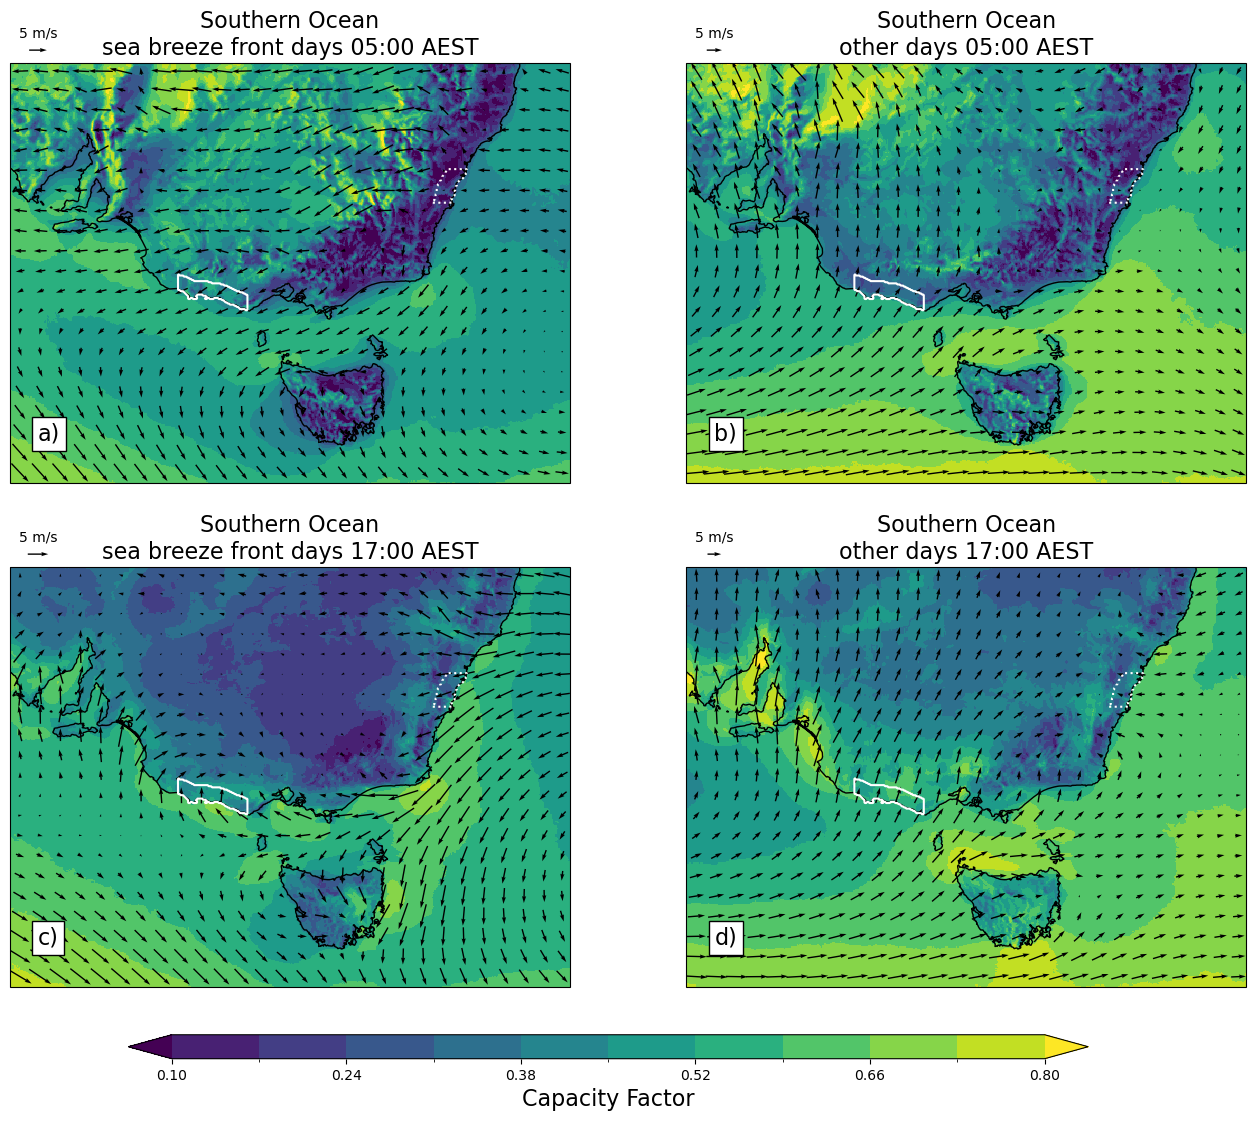

In [17]:
plt.figure(figsize=[16,12])

ax1=plt.subplot(2,2,1,projection=ccrs.PlateCarree())
ax2=plt.subplot(2,2,2,projection=ccrs.PlateCarree())
plot_map(southern_sb.sel(season="DJF"),southern_non_sb.sel(season="DJF"),5,ax1,ax2,shapes,"southern_landsea","illawara_landsea")#,lat_slice=slice(-42,-27),lon_slice=slice(108,130))
ax1.set_title("Southern Ocean\nsea breeze front days 05:00 AEST",size=16)
ax2.set_title("Southern Ocean\nother days 05:00 AEST",size=16)
ax1.text(0.05,0.1,"a)",transform=ax1.transAxes,fontdict={"size":"16"},bbox=dict(facecolor='white'))
ax2.text(0.05,0.1,"b)",transform=ax2.transAxes,fontdict={"size":"16"},bbox=dict(facecolor='white'))

ax1=plt.subplot(2,2,3,projection=ccrs.PlateCarree())
ax2=plt.subplot(2,2,4,projection=ccrs.PlateCarree())
plot_map(southern_sb.sel(season="DJF"),southern_non_sb.sel(season="DJF"),17,ax1,ax2,shapes,"southern_landsea","illawara_landsea")#,lat_slice=slice(-42,-27),lon_slice=slice(108,130))
ax1.set_title("Southern Ocean\nsea breeze front days 17:00 AEST",size=16)
ax2.set_title("Southern Ocean\nother days 17:00 AEST",size=16)
ax1.text(0.05,0.1,"c)",transform=ax1.transAxes,fontdict={"size":"16"},bbox=dict(facecolor='white'))
ax2.text(0.05,0.1,"d)",transform=ax2.transAxes,fontdict={"size":"16"},bbox=dict(facecolor='white'))


cb=plt.colorbar(c,cax=plt.axes([0.2,0.05,0.6,0.02]),orientation="horizontal")
cb.set_label("Capacity Factor",size=16)

plt.savefig("/g/data/ng72/ab4502/figs/wind_energy_paper/southern_composite_map.jpeg",bbox_inches="tight",dpi=300)

In [18]:
uname = "ua100m"
vname = "va100m"

files = np.sort(glob.glob("/scratch/ng72/ab4502/hourly_composites/barra_c/barra_c_hourly_"+uname+"_"+vname+"*.nc"))
file_dates = [pd.to_datetime(f.split("/")[-1].split("_")[-2]) for f in files]
file_years = np.array([d.year for d in file_dates])
file_months = np.array([d.month for d in file_dates])

In [19]:
hourly_cf_djf = xr.open_mfdataset(
    files[np.in1d(file_months,[12,1,2])],
    concat_dim=xr.DataArray(np.array(file_dates)[np.in1d(file_months,[12,1,2])],dims="month"),
    combine="nested"
).cf.sel(lat=shapes.lat,lon=shapes.lon).persist()

hourly_cf_jja = xr.open_mfdataset(
    files[np.in1d(file_months,[6,7,8])],
    concat_dim=xr.DataArray(np.array(file_dates)[np.in1d(file_months,[6,7,8])],dims="month"),
    combine="nested"
).cf.sel(lat=shapes.lat,lon=shapes.lon).persist()

hourly_cf_djf["hour"] = (hourly_cf_djf.hour + 10) % 24
hourly_cf_jja["hour"] = (hourly_cf_jja.hour + 10) % 24

In [20]:
hourly_cf_djf_bunbury = xr.open_mfdataset(
    files[np.in1d(file_months,[12,1,2])],
    concat_dim=xr.DataArray(np.array(file_dates)[np.in1d(file_months,[12,1,2])],dims="month"),
    combine="nested"
).cf.sel(lat=shapes_bunbury.lat,lon=shapes_bunbury.lon).persist()

hourly_cf_jja_bunbury = xr.open_mfdataset(
    files[np.in1d(file_months,[6,7,8])],
    concat_dim=xr.DataArray(np.array(file_dates)[np.in1d(file_months,[6,7,8])],dims="month"),
    combine="nested"
).cf.sel(lat=shapes_bunbury.lat,lon=shapes_bunbury.lon).persist()

hourly_cf_djf_bunbury["hour"] = (hourly_cf_djf_bunbury.hour + 8) % 24
hourly_cf_jja_bunbury["hour"] = (hourly_cf_jja_bunbury.hour + 8) % 24

In [21]:
hourly_cf_djf = hourly_cf_djf.sortby("hour")
hourly_cf_jja = hourly_cf_jja.sortby("hour")

hourly_cf_djf_bunbury = hourly_cf_djf_bunbury.sortby("hour")
hourly_cf_jja_bunbury = hourly_cf_jja_bunbury.sortby("hour")

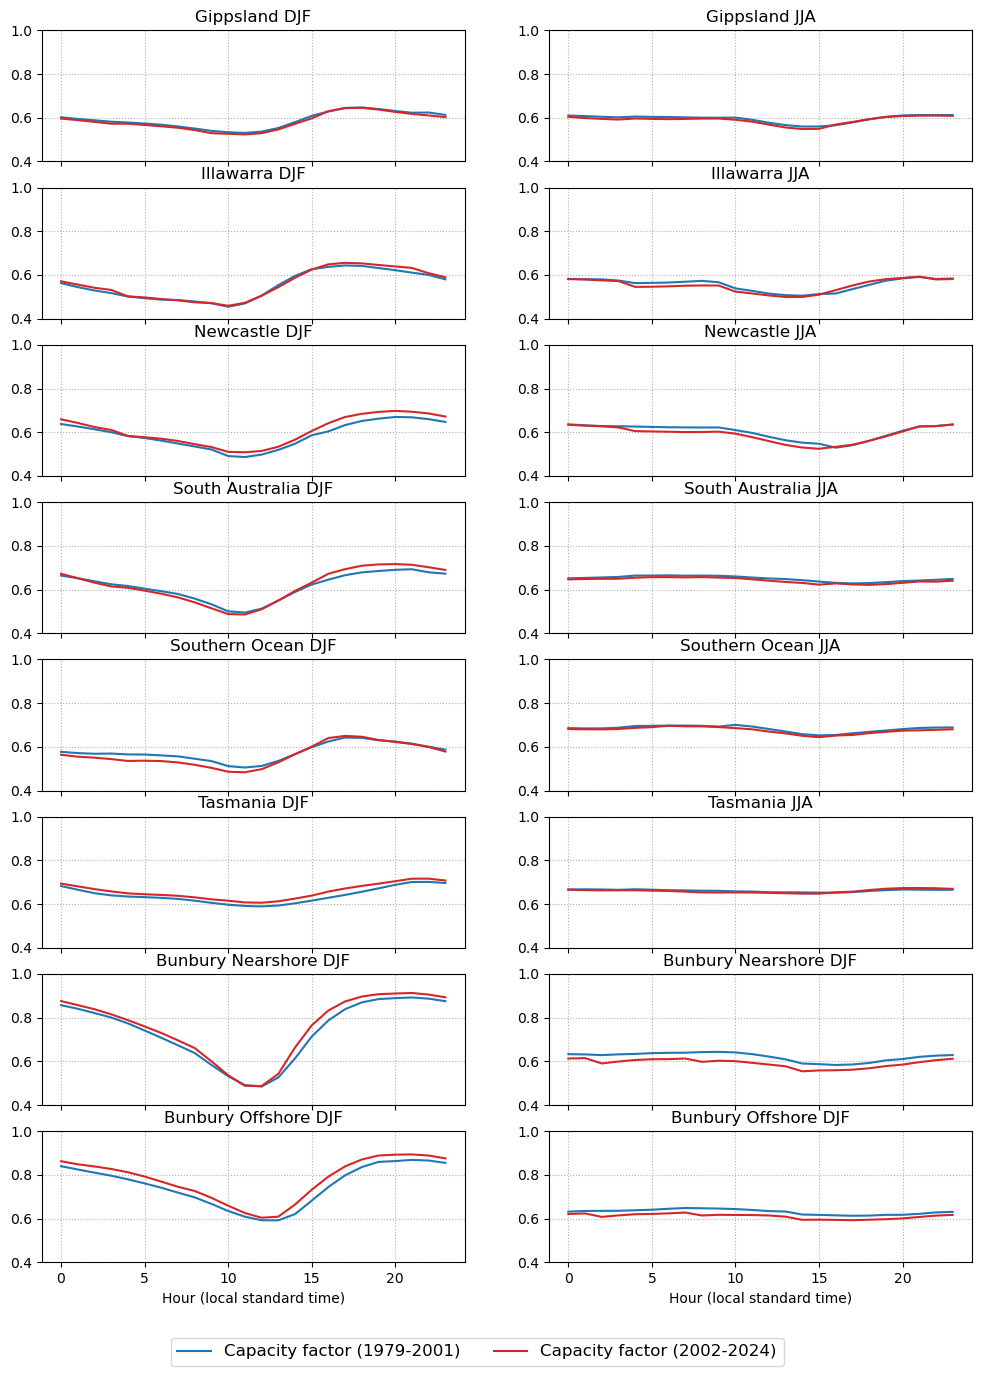

In [22]:
def plot(ax, cf_ds1, cf_ds2, mask, title="", xticklabels=False):

    l1=xr.where(
            mask,
            cf_ds1,
            np.nan).mean(("lat","lon","month")).plot(color="tab:blue")
    
    l2=xr.where(
            mask,
            cf_ds2,
            np.nan).mean(("lat","lon","month")).plot(color="tab:red")
    plt.ylim([0.4,1])
    plt.title(title)

    ax.grid(ls=":")
    ax.set_xlabel("")

    if xticklabels:
        pass
    else:
        ax.set_xticklabels("")

    return l1, l2


fig=plt.figure(figsize=[12,16])


plot(
    plt.subplot(8,2,1),
    hourly_cf_djf.sel(month=hourly_cf_djf.month.dt.year<=2001),
    hourly_cf_djf.sel(month=hourly_cf_djf.month.dt.year>=2002),
    shapes.rez_mask==27,
    title="Gippsland DJF"
)
plot(
    plt.subplot(8,2,2),
    hourly_cf_jja.sel(month=hourly_cf_jja.month.dt.year<=2001),
    hourly_cf_jja.sel(month=hourly_cf_jja.month.dt.year>=2002),
    shapes.rez_mask==27,
    title="Gippsland JJA"
)


plot(
    plt.subplot(8,2,3),
    hourly_cf_djf.sel(month=hourly_cf_djf.month.dt.year<=2001),
    hourly_cf_djf.sel(month=hourly_cf_djf.month.dt.year>=2002),
    shapes.rez_mask==19,
    title="Illawarra DJF"
)
plot(
    plt.subplot(8,2,4),
    hourly_cf_jja.sel(month=hourly_cf_jja.month.dt.year<=2001),
    hourly_cf_jja.sel(month=hourly_cf_jja.month.dt.year>=2002),
    shapes.rez_mask==19,
    title="Illawarra JJA"
)


plot(
    plt.subplot(8,2,5),
    hourly_cf_djf.sel(month=hourly_cf_djf.month.dt.year<=2001),
    hourly_cf_djf.sel(month=hourly_cf_djf.month.dt.year>=2002),
    shapes.rez_mask==18,
    title="Newcastle DJF"
)
plot(
    plt.subplot(8,2,6),
    hourly_cf_jja.sel(month=hourly_cf_jja.month.dt.year<=2001),
    hourly_cf_jja.sel(month=hourly_cf_jja.month.dt.year>=2002),
    shapes.rez_mask==18,
    title="Newcastle JJA"
)


plot(
    plt.subplot(8,2,7),
    hourly_cf_djf.sel(month=hourly_cf_djf.month.dt.year<=2001),
    hourly_cf_djf.sel(month=hourly_cf_djf.month.dt.year>=2002),
    shapes.rez_mask==38,
    title="South Australia DJF"
)
plot(
    plt.subplot(8,2,8),
    hourly_cf_jja.sel(month=hourly_cf_jja.month.dt.year<=2001),
    hourly_cf_jja.sel(month=hourly_cf_jja.month.dt.year>=2002),
    shapes.rez_mask==38,
    title="South Australia JJA"
)


plot(
    plt.subplot(8,2,9),
    hourly_cf_djf.sel(month=hourly_cf_djf.month.dt.year<=2001),
    hourly_cf_djf.sel(month=hourly_cf_djf.month.dt.year>=2002),
    shapes.rez_mask==28,
    title="Southern Ocean DJF"
)
plot(
    plt.subplot(8,2,10),
    hourly_cf_jja.sel(month=hourly_cf_jja.month.dt.year<=2001),
    hourly_cf_jja.sel(month=hourly_cf_jja.month.dt.year>=2002),
    shapes.rez_mask==28,
    title="Southern Ocean JJA"
)


plot(
    plt.subplot(8,2,11),
    hourly_cf_djf.sel(month=hourly_cf_djf.month.dt.year<=2001),
    hourly_cf_djf.sel(month=hourly_cf_djf.month.dt.year>=2002),
    shapes.rez_mask==42,
    title="Tasmania DJF"
)
plot(
    plt.subplot(8,2,12),
    hourly_cf_jja.sel(month=hourly_cf_jja.month.dt.year<=2001),
    hourly_cf_jja.sel(month=hourly_cf_jja.month.dt.year>=2002),
    shapes.rez_mask==42,
    title="Tasmania JJA"
)


plot(
    plt.subplot(8,2,13),
    hourly_cf_djf_bunbury.sel(month=hourly_cf_djf_bunbury.month.dt.year<=2001),
    hourly_cf_djf_bunbury.sel(month=hourly_cf_djf_bunbury.month.dt.year>=2002),
    shapes_bunbury.rez_mask==43,
    title="Bunbury Nearshore DJF"
)
plot(
    plt.subplot(8,2,14),
    hourly_cf_jja_bunbury.sel(month=hourly_cf_jja_bunbury.month.dt.year<=2001),
    hourly_cf_jja_bunbury.sel(month=hourly_cf_jja_bunbury.month.dt.year>=2002),
    shapes_bunbury.rez_mask==43,
    title="Bunbury Nearshore DJF"
)



plot(
    plt.subplot(8,2,15),
    hourly_cf_djf_bunbury.sel(month=hourly_cf_djf_bunbury.month.dt.year<=2001),
    hourly_cf_djf_bunbury.sel(month=hourly_cf_djf_bunbury.month.dt.year>=2002),
    shapes_bunbury.rez_mask==44,
    title="Bunbury Offshore DJF",
    xticklabels=True
)
plt.xlabel("Hour (local standard time)")

l1,l2=plot(
    plt.subplot(8,2,16),
    hourly_cf_jja_bunbury.sel(month=hourly_cf_jja_bunbury.month.dt.year<=2001),
    hourly_cf_jja_bunbury.sel(month=hourly_cf_jja_bunbury.month.dt.year>=2002),
    shapes_bunbury.rez_mask==44,
    title="Bunbury Offshore DJF",
    xticklabels=True
)
plt.xlabel("Hour (local standard time)")

fig.legend([l1[0],l2[0]],
           ["Capacity factor (1979-2001)","Capacity factor (2002-2024)"],
           loc="lower right", bbox_to_anchor=[0.75,0.04],ncols=2,fontsize="large")

plt.savefig("/g/data/ng72/ab4502/figs/wind_energy_paper/cf_diurnal_trend.jpeg",bbox_inches="tight",dpi=300)